
  Единственная точка
  f(x) = -3.0·x₁ + -2.0·x₂  →  min
    1.0·x₁ + 2.0·x₂ <= 7.0
    2.0·x₁ + 1.0·x₂ <= 8.0
    0.0·x₁ + 1.0·x₂ <= 3.0
    x₁ >= 0,  x₂ >= 0

  Антиградиент  -df = (0.8321, 0.5547)

  >> ЕДИНСТВЕННАЯ ТОЧКА: x* = [3.0, 2.0],  f* = -13.0


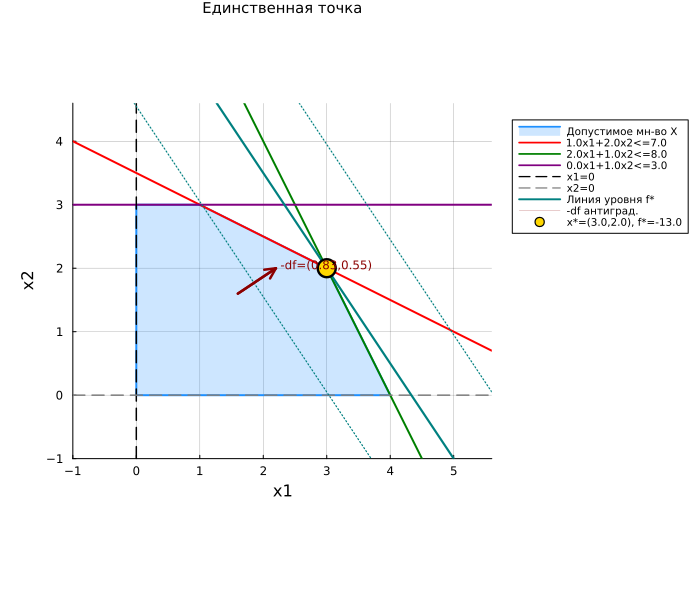

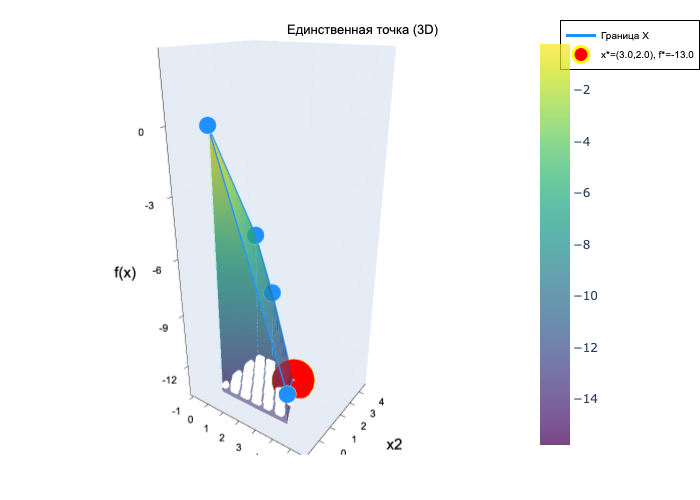


  Оптимальный отрезок
  f(x) = -1.0·x₁ + -2.0·x₂  →  min
    1.0·x₁ + 2.0·x₂ <= 7.0
    2.0·x₁ + 1.0·x₂ <= 8.0
    0.0·x₁ + 1.0·x₂ <= 3.0
    x₁ >= 0,  x₂ >= 0

  Антиградиент  -df = (0.4472, 0.8944)

  >> ОПТИМАЛЬНЫЙ ОТРЕЗОК: [3.0, 2.0] - [1.0, 3.0],  f* = -7.0


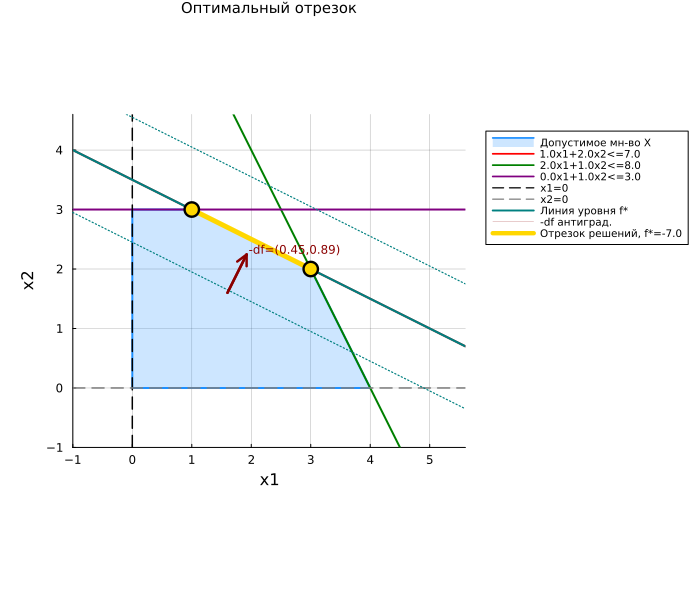

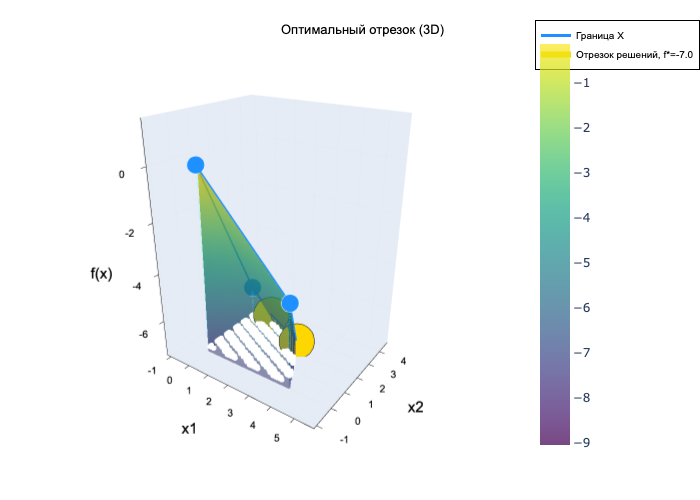


  Функция неограниченно убывает
  f(x) = -1.0·x₁ + -2.0·x₂  →  min
    -1.0·x₁ + -1.0·x₂ <= -1.0
    -2.0·x₁ + 1.0·x₂ <= 1.0
    1.0·x₁ + -2.0·x₂ <= 0.0
    x₁ >= 0,  x₂ >= 0

  Антиградиент  -df = (0.4472, 0.8944)

  >> ФУНКЦИЯ НЕОГРАНИЧЕННО УБЫВАЕТ - решения нет


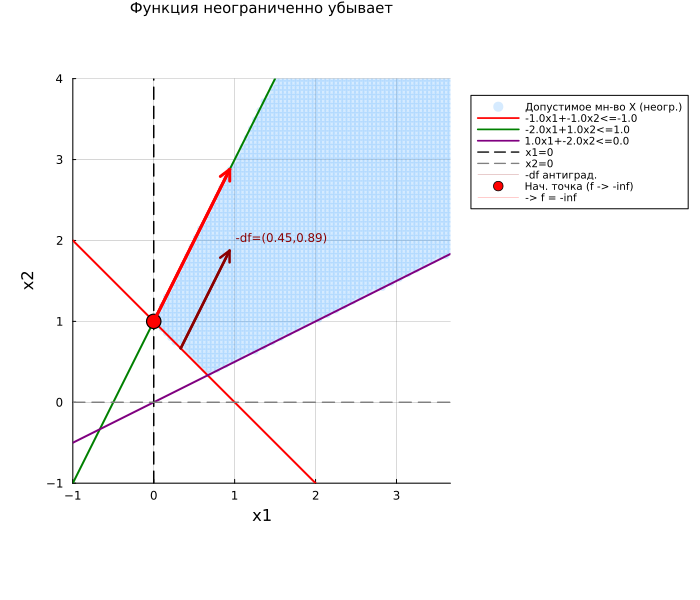

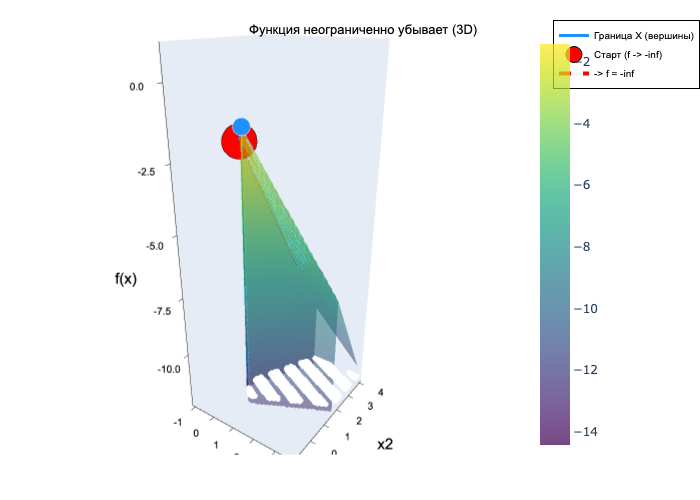


  Решений нет
  f(x) = 1.0·x₁ + 1.0·x₂  →  min
    1.0·x₁ + 0.0·x₂ <= -2.0
    0.0·x₁ + 1.0·x₂ <= -3.0
    x₁ >= 0,  x₂ >= 0

  >> РЕШЕНИЙ НЕТ - допустимое множество пусто


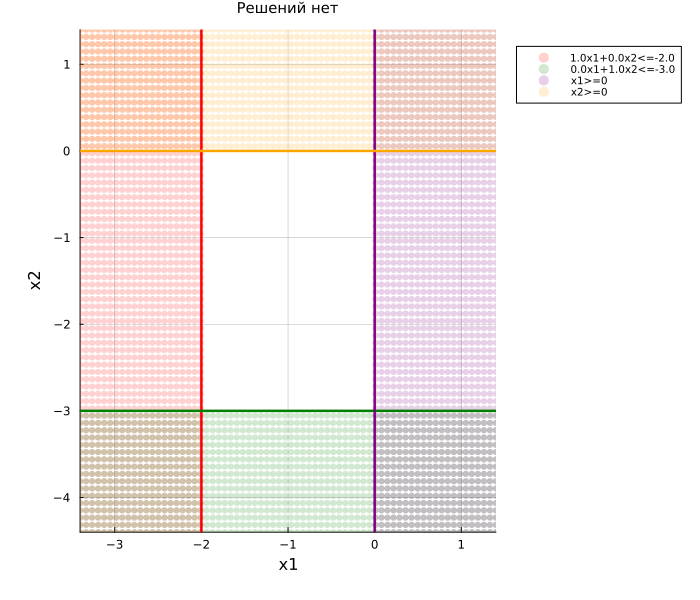

In [24]:
using Plots, LinearAlgebra, Combinatorics, Statistics


struct LPProblem
    c::Vector{Float64}
    A::Matrix{Float64}
    b::Vector{Float64}
    name::String
end


function line_intersection(a1, b1, a2, b2)
    M = [a1[1] a1[2]; a2[1] a2[2]]
    abs(det(M)) < 1e-12 && return nothing
    return M \ [b1; b2]
end

function feasible_vertices(A::Matrix, b::Vector)
    A_ext = vcat(A, [-1.0 0.0; 0.0 -1.0])
    b_ext = vcat(b, [0.0, 0.0])
    vertices = Vector{Vector{Float64}}()
    for pair in combinations(1:size(A_ext,1), 2)
        pt = line_intersection(A_ext[pair[1],:], b_ext[pair[1]],
                               A_ext[pair[2],:], b_ext[pair[2]])
        pt === nothing && continue
        all(A_ext * pt .<= b_ext .+ 1e-8) && push!(vertices, pt)
    end
    unique_v = Vector{Vector{Float64}}()
    for v in vertices
        any(norm(v .- u) < 1e-6 for u in unique_v) || push!(unique_v, v)
    end
    return unique_v
end

function sort_ccw(verts)
    length(verts) < 2 && return verts
    cx = mean(v[1] for v in verts)
    cy = mean(v[2] for v in verts)
    return sort(verts; by = v -> atan(v[2]-cy, v[1]-cx))
end

function is_bounded(prob::LPProblem)
    A_ext = vcat(prob.A, [-1.0 0.0; 0.0 -1.0])
    b_ext = vcat(prob.b, [0.0, 0.0])
    for θ in range(0, 2π; length=9)[1:end-1]
        d = [cos(θ), sin(θ)]
        v = feasible_vertices(prob.A, prob.b)
        isempty(v) && return true
        all(A_ext * (v[1] + 1e7 .* d) .<= b_ext .+ 1e-4) && return false
    end
    return true
end

function plot_ranges(prob::LPProblem; extra=0.0)
    verts = feasible_vertices(prob.A, prob.b)
    all_x = isempty(verts) ? [0.0, 5.0] : [v[1] for v in verts]
    all_y = isempty(verts) ? [0.0, 5.0] : [v[2] for v in verts]
    span  = max(3.0, maximum(all_x)-minimum(all_x), maximum(all_y)-minimum(all_y))
    mg    = (0.4 + extra) * span
    x_lo  = max(-1.0, minimum(all_x)-mg);  x_hi = maximum(all_x)+mg
    y_lo  = max(-1.0, minimum(all_y)-mg);  y_hi = maximum(all_y)+mg
    return x_lo, x_hi, y_lo, y_hi, mg
end

function draw_feasible_region!(p, prob::LPProblem, x_lo, x_hi, y_lo, y_hi;
                               n=90, color=:dodgerblue, alpha=0.15, label="Допустимое мн-во X")
    A_ext = vcat(prob.A, [-1.0 0.0; 0.0 -1.0])
    b_ext = vcat(prob.b, [0.0, 0.0])
    fx = Float64[]; fy = Float64[]
    for x in range(x_lo, x_hi; length=n), y in range(y_lo, y_hi; length=n)
        all(A_ext * [x,y] .<= b_ext .+ 1e-8) && (push!(fx,x); push!(fy,y))
    end
    isempty(fx) && return
    scatter!(p, fx, fy; markersize=3.5, markeralpha=alpha,
             color=color, markerstrokewidth=0, label=label)
end


function solve_lp(prob::LPProblem)
    verts = feasible_vertices(prob.A, prob.b)
    isempty(verts) && return (:no_solution, nothing, nothing, nothing)

    f_vals = [dot(prob.c, v) for v in verts]
    f_min  = minimum(f_vals)
    opt_v  = [verts[i] for i in eachindex(verts) if abs(f_vals[i]-f_min) < 1e-6]
    e      = -prob.c / max(norm(prob.c), 1e-12)

    A_ext = vcat(prob.A, [-1.0 0.0; 0.0 -1.0])
    b_ext = vcat(prob.b, [0.0, 0.0])
    all(A_ext * (opt_v[1] + 1e6*e) .<= b_ext .+ 1e-4) && return (:unbounded, opt_v[1], nothing, e)

    length(opt_v) == 1 && return (:point, opt_v[1], f_min, e)
    return (:segment, opt_v, f_min, e)
end


function print_result(prob, status, solution, f_opt, antigrad)
    println("\n", "="^62)
    println("  ", prob.name)
    println("="^62)
    println("  f(x) = $(prob.c[1])·x₁ + $(prob.c[2])·x₂  →  min")
    for i in 1:size(prob.A,1)
        println("    $(prob.A[i,1])·x₁ + $(prob.A[i,2])·x₂ <= $(prob.b[i])")
    end
    println("    x₁ >= 0,  x₂ >= 0")
    !isnothing(antigrad) &&
        println("\n  Антиградиент  -df = ($(round(antigrad[1],digits=4)), $(round(antigrad[2],digits=4)))")
    msg = if status == :no_solution
        "РЕШЕНИЙ НЕТ - допустимое множество пусто"
    elseif status == :point
        "ЕДИНСТВЕННАЯ ТОЧКА: x* = $(round.(solution,digits=4)),  f* = $(round(f_opt,digits=6))"
    elseif status == :segment
        "ОПТИМАЛЬНЫЙ ОТРЕЗОК: $(round.(solution[1],digits=4)) - $(round.(solution[end],digits=4)),  f* = $(round(f_opt,digits=6))"
    else
        "ФУНКЦИЯ НЕОГРАНИЧЕННО УБЫВАЕТ - решения нет"
    end
    println("\n  >> $msg")
    println("="^62)
end


function plot2d(prob::LPProblem, status, solution, f_opt, antigrad; title_str="")
    gr()

    verts = feasible_vertices(prob.A, prob.b)

    if status == :no_solution
        all_A = vcat(prob.A, [-1.0 0.0; 0.0 -1.0])
        all_b = vcat(prob.b, [0.0, 0.0])
        ipts  = Vector{Vector{Float64}}()
        m_all = size(all_A, 1)
        for i in 1:m_all, j in i+1:m_all
            pt = line_intersection(all_A[i,:], all_b[i], all_A[j,:], all_b[j])
            pt !== nothing && push!(ipts, pt)
        end
        if isempty(ipts)
            x_lo, x_hi, y_lo, y_hi, mg = -5.0, 5.0, -5.0, 5.0, 2.0
        else
            xs_i = [p[1] for p in ipts]; ys_i = [p[2] for p in ipts]
            span = max(4.0, maximum(xs_i)-minimum(xs_i), maximum(ys_i)-minimum(ys_i))
            mg   = 0.35 * span
            x_lo = minimum(xs_i) - mg;  x_hi = maximum(xs_i) + mg
            y_lo = minimum(ys_i) - mg;  y_hi = maximum(ys_i) + mg
        end
    else
        x_lo, x_hi, y_lo, y_hi, mg = plot_ranges(prob; extra = status==:unbounded ? 0.6 : 0.0)
    end
    xs = range(x_lo, x_hi; length=500)

    p = plot(; title=title_str, xlabel="x1", ylabel="x2",
               xlims=(x_lo, x_hi), ylims=(y_lo, y_hi),
               legend=:outertopright, aspect_ratio=:equal,
               size=(700,600), background_color=:white,
               grid=true, gridalpha=0.3, titlefontsize=10)

    if status == :no_solution
        all_A_ns = vcat(prob.A, [-1.0 0.0; 0.0 -1.0])
        all_b_ns = vcat(prob.b, [0.0, 0.0])
        all_lbls = vcat(
            ["$(round(prob.A[i,1],digits=1))x1+$(round(prob.A[i,2],digits=1))x2<=$(round(prob.b[i],digits=1))"
             for i in 1:size(prob.A,1)],
            ["x1>=0", "x2>=0"]
        )
        clrs = [:red, :green, :purple, :orange, :brown, :magenta, :cyan, :blue]
        for i in 1:size(all_A_ns,1)
            a1, a2, bi = all_A_ns[i,1], all_A_ns[i,2], all_b_ns[i]
            clr = clrs[mod1(i, length(clrs))]
            hx = Float64[]; hy = Float64[]
            for x in range(x_lo, x_hi; length=70), y in range(y_lo, y_hi; length=70)
                a1*x + a2*y <= bi + 1e-9 && (push!(hx,x); push!(hy,y))
            end
            isempty(hx) && continue
            scatter!(p, hx, hy; markersize=3.5, markeralpha=0.18,
                     color=clr, markerstrokewidth=0, label=all_lbls[i])
        end
        for i in 1:size(all_A_ns,1)
            a1, a2, bi = all_A_ns[i,1], all_A_ns[i,2], all_b_ns[i]
            clr = clrs[mod1(i, length(clrs))]
            if abs(a2) > 1e-10
                plot!(p, collect(xs), @.((bi - a1*xs)/a2); linewidth=2.5, color=clr, label=false)
            elseif abs(a1) > 1e-10
                vline!(p, [bi/a1]; linewidth=2.5, color=clr, label=false)
            end
        end

    else
        if !isempty(verts)
            if is_bounded(prob)
                sv = sort_ccw(verts)
                px = [v[1] for v in sv]; push!(px, px[1])
                py = [v[2] for v in sv]; push!(py, py[1])
                plot!(p, px, py; fill=true, fillalpha=0.22, fillcolor=:dodgerblue,
                      linewidth=2, linecolor=:dodgerblue, label="Допустимое мн-во X")
            else
                draw_feasible_region!(p, prob, x_lo, x_hi, y_lo, y_hi;
                                      n=90, color=:dodgerblue, alpha=0.18,
                                      label="Допустимое мн-во X (неогр.)")
            end
        end

        line_clrs = [:red, :green, :purple, :orange, :brown, :magenta, :cyan]
        for i in 1:size(prob.A,1)
            a1, a2, bi = prob.A[i,1], prob.A[i,2], prob.b[i]
            clr = line_clrs[mod1(i, length(line_clrs))]
            lbl = "$(round(a1,digits=2))x1+$(round(a2,digits=2))x2<=$(round(bi,digits=2))"
            if abs(a2) > 1e-10
                plot!(p, collect(xs), @.((bi - a1*xs)/a2); linewidth=2, color=clr, label=lbl)
            elseif abs(a1) > 1e-10
                vline!(p, [bi/a1]; linewidth=2, color=clr, label=lbl)
            end
        end
        vline!(p, [0.0]; color=:black, linewidth=1.5, linestyle=:dash, label="x1=0")
        hline!(p, [0.0]; color=:gray,  linewidth=1.5, linestyle=:dash, label="x2=0")

        if !isempty(verts) && status ∉ (:unbounded,) && !isnothing(antigrad)
            c1, c2 = prob.c
            fc     = status == :point ? dot(prob.c, solution) : dot(prob.c, solution[1])
            sc_lv  = max(1.0, abs(fc)) * 0.3
            for (dt, sty, lw, lbl) in [(-sc_lv,:dot,1.2,""), (0.0,:solid,2.2,"Линия уровня f*"), (sc_lv,:dot,1.2,"")]
                abs(c2) > 1e-10 || continue
                plot!(p, collect(xs), @.((fc+dt - c1*xs)/c2);
                      color=:teal, linewidth=lw, linestyle=sty, label=lbl)
            end
        end

        if !isempty(verts) && !isnothing(antigrad)
            ox = mean(v[1] for v in verts)
            oy = mean(v[2] for v in verts)
            arrow_len = mg * 0.45
            ex = ox + antigrad[1] * arrow_len
            ey = oy + antigrad[2] * arrow_len
            if ex < x_lo || ex > x_hi || ey < y_lo || ey > y_hi
                t_max = min(
                    antigrad[1] > 0 ? (x_hi-ox)/antigrad[1] : (ox-x_lo)/(-antigrad[1]+1e-12),
                    antigrad[2] > 0 ? (y_hi-oy)/antigrad[2] : (oy-y_lo)/(-antigrad[2]+1e-12)
                )
                arrow_len = min(arrow_len, t_max * 0.85)
                ex = ox + antigrad[1] * arrow_len
                ey = oy + antigrad[2] * arrow_len
            end
            quiver!(p, [ox], [oy];
                    quiver=([antigrad[1]*arrow_len], [antigrad[2]*arrow_len]),
                    color=:darkred, linewidth=2.5)
            annotate!(p, ex + antigrad[1]*mg*0.06, ey + antigrad[2]*mg*0.06,
                      text("-df=($(round(antigrad[1],digits=2)),$(round(antigrad[2],digits=2)))",
                           :darkred, 8, :left))
            plot!(p, [ox, ex], [oy, ey]; linewidth=0, color=:darkred, label="-df антиград.")
        end

        if status == :point
            scatter!(p, [solution[1]], [solution[2]];
                     markersize=10, color=:gold,
                     markerstrokecolor=:black, markerstrokewidth=2,
                     label="x*=($(round(solution[1],digits=3)),$(round(solution[2],digits=3))), f*=$(round(f_opt,digits=4))")
        elseif status == :segment
            sx = [s[1] for s in solution]; sy = [s[2] for s in solution]
            plot!(p, sx, sy; linewidth=5, color=:gold,
                  label="Отрезок решений, f*=$(round(f_opt,digits=4))")
            scatter!(p, sx, sy; markersize=8, color=:gold,
                     markerstrokecolor=:black, markerstrokewidth=2, label="")
        elseif status == :unbounded && !isnothing(solution)
            scatter!(p, [solution[1]], [solution[2]];
                     markersize=8, color=:red, label="Нач. точка (f -> -inf)")
            if !isnothing(antigrad)
                sc3 = mg * 0.7
                quiver!(p, [solution[1]], [solution[2]];
                        quiver=([antigrad[1]*sc3], [antigrad[2]*sc3]),
                        color=:red, linewidth=3)
                plot!(p, [solution[1], solution[1]+antigrad[1]*sc3],
                         [solution[2], solution[2]+antigrad[2]*sc3];
                      linewidth=0, color=:red, label="-> f = -inf")
            end
        end
    end

    return p
end


function plot3d_interactive(prob::LPProblem, status, solution, f_opt; title_str="")
    plotlyjs()

    verts = feasible_vertices(prob.A, prob.b)
    isempty(verts) && return plot(; title=title_str*" (3D: нет допустимого мн-ва)",
                                    xlabel="x1", ylabel="x2", zlabel="f(x)", size=(660,500))

    x_lo, x_hi, y_lo, y_hi, mg = plot_ranges(prob; extra = status==:unbounded ? 0.6 : 0.0)
    x_lo = x_lo < x_hi - 1e-6 ? x_lo : x_hi - 1.0
    y_lo = y_lo < y_hi - 1e-6 ? y_lo : y_hi - 1.0

    xs = range(x_lo, x_hi; length=65)
    ys = range(y_lo, y_hi; length=65)

    A_ext = vcat(prob.A, [-1.0 0.0; 0.0 -1.0])
    b_ext = vcat(prob.b, [0.0, 0.0])

    Z = [all(A_ext*[x,y] .<= b_ext.+1e-8) ? dot(prob.c,[x,y]) : NaN for y in ys, x in xs]
    valid = filter(!isnan, vec(Z))
    isempty(valid) && return plot(; title=title_str*" (3D: нет данных)",
                                    xlabel="x1", ylabel="x2", zlabel="f(x)", size=(660,500))

    z_lo  = minimum(valid);  z_hi = maximum(valid)
    z_lo < z_hi - 1e-6 || (z_lo -= 0.5; z_hi += 0.5)
    z_floor     = z_lo - abs(z_lo)*0.15 - 1.0
    contour3d_z = z_lo - 0.05*(z_hi-z_lo)

    Z_display = copy(Z)
    Z_display[isnan.(Z_display)] .= z_floor

    p3 = surface(xs, ys, Z_display;
                 title    = title_str * " (3D)",
                 xlabel   = "x1", ylabel = "x2", zlabel = "f(x)",
                 zlims    = (z_lo - 0.08*(z_hi-z_lo), z_hi + 0.25*(z_hi-z_lo)),
                 color    = :viridis, alpha = 0.72,
                 colorbar = true, camera = (35, 25),
                 size     = (660, 520), titlefontsize = 9, label = false)

    for level in range(z_lo, z_hi; length=7)
        pts_x = Float64[]; pts_y = Float64[]
        for (j,x) in enumerate(xs), (i,y) in enumerate(ys)
            isnan(Z[i,j]) && continue
            abs(Z[i,j]-level) < (z_hi-z_lo)*0.04 && (push!(pts_x,x); push!(pts_y,y))
        end
        isempty(pts_x) && continue
        scatter!(p3, pts_x, pts_y, fill(contour3d_z, length(pts_x));
                 markersize=1.5, markeralpha=0.35, color=:white,
                 markerstrokewidth=0, label=false)
    end

    if is_bounded(prob)
        sv = sort_ccw(verts); push!(sv, sv[1])
        plot!(p3, [v[1] for v in sv], [v[2] for v in sv], [dot(prob.c,v) for v in sv];
              linewidth=3, color=:dodgerblue, label="Граница X")
    else
        sv = sort_ccw(verts)
        if length(sv) >= 2
            plot!(p3, [v[1] for v in sv], [v[2] for v in sv], [dot(prob.c,v) for v in sv];
                  linewidth=3, color=:dodgerblue, label="Граница X (вершины)")
            scatter!(p3, [v[1] for v in sv], [v[2] for v in sv], [dot(prob.c,v) for v in sv];
                     markersize=5, color=:dodgerblue, markerstrokecolor=:white, label=false)
        end
        A_ext2 = vcat(prob.A, [-1.0 0.0; 0.0 -1.0])
        b_ext2 = vcat(prob.b, [0.0, 0.0])
        for v in verts, θ in range(0, 2π; length=37)[1:end-1]
            d   = [cos(θ), sin(θ)]
            tip = v + mg*0.8 .* d
            all(A_ext2 * tip .<= b_ext2 .+ 1e-6) || continue
            plot!(p3, [v[1],tip[1]], [v[2],tip[2]], [dot(prob.c,v), dot(prob.c,tip)];
                  linewidth=1.5, color=:dodgerblue, alpha=0.4, linestyle=:dot, label=false)
        end
    end

    for v in verts
        fv = dot(prob.c, v)
        plot!(p3, [v[1],v[1]], [v[2],v[2]], [contour3d_z,fv];
              linewidth=1.5, color=:dodgerblue, linestyle=:dot, alpha=0.5, label=false)
        scatter!(p3, [v[1]], [v[2]], [fv];
                 markersize=5, color=:dodgerblue, markerstrokecolor=:white, label=false)
    end

    if status == :point
        fv = dot(prob.c, solution)
        d  = mg * 0.08
        for (dx,dy) in [(d,0),(-d,0),(0,d),(0,-d),(d*.7,d*.7),(-d*.7,d*.7),(d*.7,-d*.7),(-d*.7,-d*.7)]
            plot!(p3, [solution[1],solution[1]+dx], [solution[2],solution[2]+dy], [fv,fv];
                  linewidth=2, color=:yellow, label=false)
        end
        scatter!(p3, [solution[1]], [solution[2]], [fv];
                 markersize=12, color=:red, markerstrokecolor=:yellow, markerstrokewidth=3,
                 label="x*=($(round(solution[1],digits=3)),$(round(solution[2],digits=3))), f*=$(round(fv,digits=4))")

    elseif status == :segment
        sx = [s[1] for s in solution]; sy = [s[2] for s in solution]
        sf = [dot(prob.c,s) for s in solution]
        plot!(p3, sx, sy, sf; linewidth=6, color=:gold,
              label="Отрезок решений, f*=$(round(f_opt,digits=4))")
        scatter!(p3, sx, sy, sf; markersize=10, color=:gold,
                 markerstrokecolor=:black, markerstrokewidth=2, label="")

    elseif status == :unbounded
        fv           = dot(prob.c, solution)
        local_ag     = -prob.c / max(norm(prob.c), 1e-12)
        ray_end      = solution + local_ag * mg * 0.8
        scatter!(p3, [solution[1]], [solution[2]], [fv];
                 markersize=10, color=:red, markerstrokecolor=:black, label="Старт (f -> -inf)")
        plot!(p3, [solution[1],ray_end[1]], [solution[2],ray_end[2]], [fv, dot(prob.c,ray_end)];
              linewidth=4, color=:red, linestyle=:dash, label="-> f = -inf")
    end

    return p3
end


function run_lp(prob::LPProblem; show_plots=true)
    status, solution, f_opt, antigrad = solve_lp(prob)
    print_result(prob, status, solution, f_opt, antigrad)
    if show_plots
        p2 = plot2d(prob, status, solution, f_opt, antigrad; title_str=prob.name)
        plot!(p2; legendfontsize=7, left_margin=5Plots.mm, bottom_margin=5Plots.mm)
        display(p2)
        if status != :no_solution
            p3 = plot3d_interactive(prob, status, solution, f_opt; title_str=prob.name)
            plot!(p3; legend=:topright, legendfontsize=7, size=(900,550))
            display(p3)
        end
    end
end

Base.invokelatest(run_lp,
    LPProblem([-3.0,-2.0], [1.0 2.0; 2.0 1.0; 0.0 1.0], [7.0,8.0,3.0],
              "Единственная точка"))

Base.invokelatest(run_lp,
    LPProblem([-1.0,-2.0], [1.0 2.0; 2.0 1.0; 0.0 1.0], [7.0,8.0,3.0],
              "Оптимальный отрезок"))

Base.invokelatest(run_lp,
    LPProblem([-1.0,-2.0], [-1.0 -1.0; -2.0 1.0; 1.0 -2.0], [-1.0,1.0,0.0],
              "Функция неограниченно убывает"))

Base.invokelatest(run_lp,
    LPProblem([1.0,1.0], [1.0 0.0; 0.0 1.0], [-2.0,-3.0],
              "Решений нет"))